# Student Performance Analysis — Task 1
### Data Science / Analysis with Python Internship

**Workflow:** Load → Clean → Analyze → Visualize → Conclude

Dataset: `student-mat.csv` — Student Performance dataset.


## Upload the CSV File

In [1]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


## 1. Load Dataset

Load the dataset using `pandas`. Note: the file is **semicolon-separated**, not comma-separated, so we pass `sep=';'`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('student-mat.csv', sep=';')

# Preview
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-nu

## 2. Explore & Clean Data

We check for missing values, duplicate rows, and confirm the shape/dtypes of the dataset before analysis.

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values: 0


In [5]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates (if any)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (395, 33)


In [6]:
# Inspect dataset shape and data types
print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes)
df.describe()

Dataset shape: (395, 33)

Data types:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


**Observation:** The dataset has no missing values and no duplicate rows, so it is already clean and ready for analysis. It contains 395 rows and 33 columns, with a mix of numeric (e.g. `age`, `G1`, `G2`, `G3`) and categorical (e.g. `sex`, `school`, `Mjob`) features.

## 3. Analysis Questions

We now answer the four core analysis questions using the cleaned data.

### 3.1 Average final grade (G3)

In [7]:
avg_g3 = df['G3'].mean()
print(f"Average final grade (G3): {avg_g3:.2f} out of 20")

Average final grade (G3): 10.42 out of 20


### 3.2 How many students scored above 15?

In [8]:
above_15 = df[df['G3'] > 15].shape[0]
pct_above_15 = (above_15 / df.shape[0]) * 100
print(f"Students who scored above 15: {above_15}")
print(f"That is {pct_above_15:.1f}% of all students")

Students who scored above 15: 40
That is 10.1% of all students


### 3.3 Is study time correlated with performance?

In [9]:
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between study time and final grade (G3): {correlation:.3f}")

if correlation > 0.3:
    strength = "a moderate to strong positive"
elif correlation > 0.1:
    strength = "a weak positive"
elif correlation > -0.1:
    strength = "almost no"
else:
    strength = "a negative"
print(f"This indicates {strength} relationship between study time and grades.")

Correlation between study time and final grade (G3): 0.098
This indicates almost no relationship between study time and grades.


### 3.4 Which gender performs better on average?

In [10]:
gender_performance = df.groupby('sex')['G3'].mean().sort_values(ascending=False)
print("Average final grade by gender:")
print(gender_performance)

better_gender = "Male" if gender_performance.idxmax() == 'M' else "Female"
print(f"\n{better_gender} students have a higher average final grade.")

Average final grade by gender:
sex
M    10.914439
F     9.966346
Name: G3, dtype: float64

Male students have a higher average final grade.


## 4. Visualizations

We create three visualizations to support the analysis above.

### 4.1 Histogram of grades

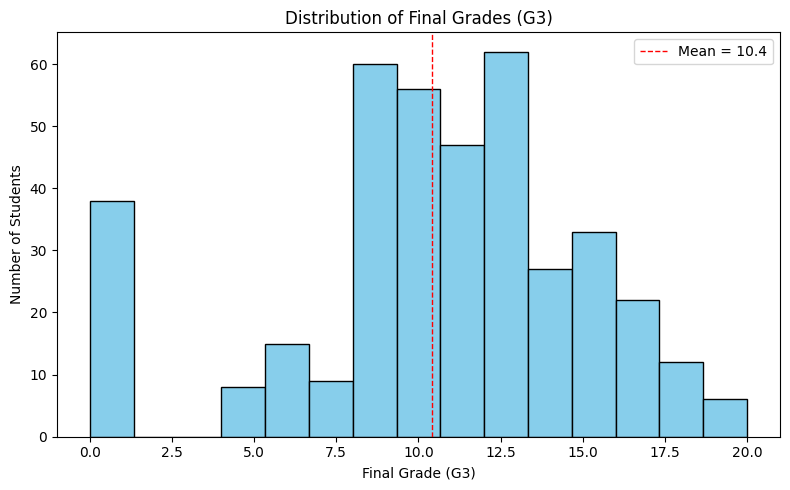

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.axvline(df['G3'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean = {df["G3"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.savefig('histogram_grades.png', dpi=150)
plt.show()

**What this shows:** The histogram displays how final grades (G3) are distributed across all 395 students. Most students cluster around the 8–14 range, with the mean (red dashed line) sitting at about 10.4. There's also a noticeable spike of students at 0 — these are likely students who dropped out or didn't complete the course, which is worth flagging as an outlier group rather than ignoring. The distribution is roughly bell-shaped but slightly skewed, confirming that very high scores (above 15) are relatively rare.





### 4.2 Scatterplot: study time vs grades

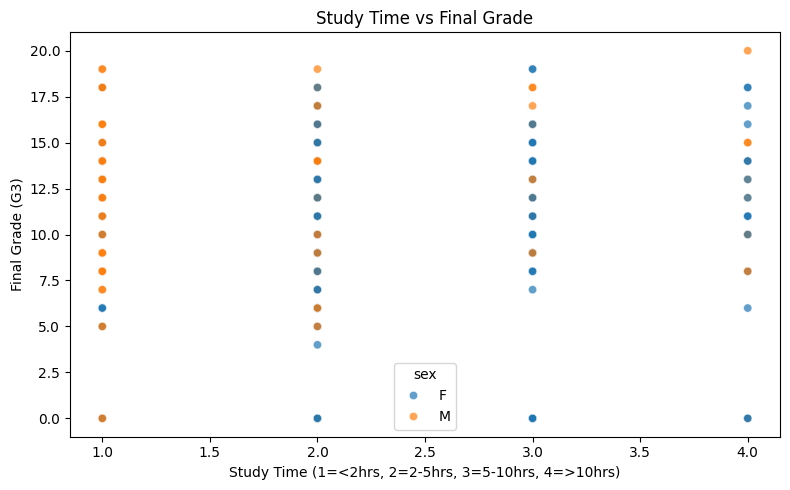

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='studytime', y='G3', hue='sex', alpha=0.7)
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('scatter_studytime_grades.png', dpi=150)
plt.show()

**What this shows:** Each point is a student, plotted by how much they study (x-axis, on a 1–4 scale) against their final grade (y-axis), colored by gender. If study time strongly predicted grades, we'd expect a clear upward trend as we move right. Instead, the points are widely scattered at every study-time level — there are high and low scorers even among students who study the least. This visually confirms the earlier finding: the correlation (~0.10) is weak, so study time alone doesn't explain much of the variation in performance.




### 4.3 Bar chart: male vs female average score

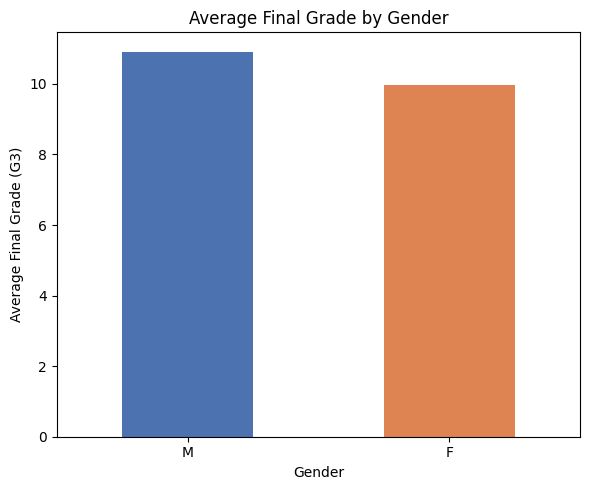

In [13]:
plt.figure(figsize=(6,5))
gender_performance.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Average Final Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Final Grade (G3)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('bar_gender_grades.png', dpi=150)
plt.show()

**What this shows:** This bar chart compares the average final grade between male and female students. The bars are close in height, meaning the gap in average performance is small — a difference of roughly 1 point on a 20-point scale. So while male students score marginally higher on average in this dataset, gender doesn't appear to be a major driver of performance compared to other factors.